Loading data...
Precomputing Distance Matrix...
Starting Sweep (1000 to 50000)...

SWEEP RESULTS (GLOBAL)
Best Mean Improvement:   15.06% at Sigma=9000
Best Median Improvement: 15.17% at Sigma=8000


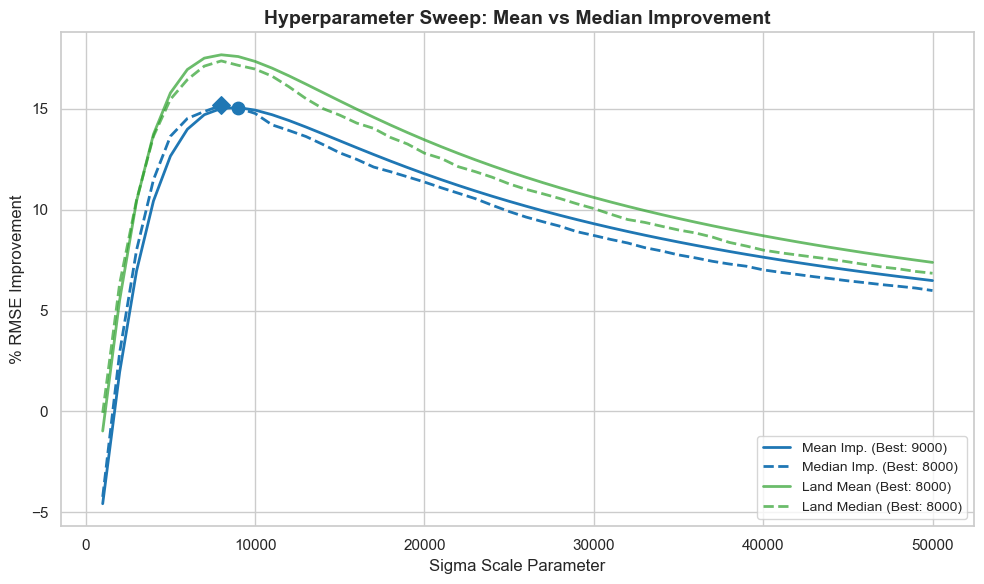

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import os
import warnings
from time import time

# --------------------------
# Config
# --------------------------
data_dir = "/Users/ewellmeyer/Documents/research/HadGEM"
save_dir = "/Users/ewellmeyer/Documents/research/HadGEM/sweep_results"
os.makedirs(save_dir, exist_ok=True)

input_file = os.path.join(data_dir, "GA789_PR_his_rg128.nc")
truth_file = os.path.join(data_dir, "GA789_dPdK_rg128.nc")
land_mask_file = os.path.join(data_dir, "hadgem_landmask_rg128.nc")

# Sweep Parameters
SIGMA_START = 1000
SIGMA_STOP = 50000
SIGMA_STEP = 1000

warnings.filterwarnings("ignore")

# --------------------------
# 1. Data Loading & Prep
# --------------------------
print("Loading data...")
ds_in = xr.open_dataset(input_file)
X_data = ds_in.to_array().values.squeeze()
ds_in.close()

ds_true = xr.open_dataset(truth_file)
y_data = ds_true.to_array().values.squeeze()
ds_true.close()

if X_data.ndim == 4: X_data = X_data[0]
if y_data.ndim == 4: y_data = y_data[0]
n_members, n_lat, n_lon = X_data.shape

# Coordinates & Mask
ds_ref = xr.open_dataset(input_file)
lats = ds_ref["latitude"].values
ds_ref.close()

try:
    ds_mask = xr.open_dataset(land_mask_file)
    mask_var = list(ds_mask.data_vars)[0]
    land_mask = ds_mask[mask_var].values.astype(bool)
    if land_mask.ndim == 3: land_mask = land_mask[0]
    ds_mask.close()
except:
    land_mask = np.ones((n_lat, n_lon), dtype=bool)

# --------------------------
# 2. Train/Test Split
# --------------------------
indices = np.arange(n_members)
train_idx, test_idx = train_test_split(indices, test_size=0.25, random_state=42)

X_train = X_data[train_idx]
y_train = y_data[train_idx]
X_test  = X_data[test_idx]
y_test  = y_data[test_idx]

# --------------------------
# 3. Precompute Distance Matrix
# --------------------------
print("Precomputing Distance Matrix...")
n_pts = n_lat * n_lon
X_train_flat = X_train.reshape(len(train_idx), n_pts)
X_test_flat  = X_test.reshape(len(test_idx), n_pts)

# Weights
lat_weights = np.cos(np.deg2rad(lats))
area_weights = np.broadcast_to(lat_weights[:, None], (n_lat, n_lon)).reshape(-1)
total_weight = np.sum(area_weights)

# Distance Matrix (N_test x N_train)
dist_matrix = np.zeros((len(test_idx), len(train_idx)))
for i in range(len(test_idx)):
    diff = X_test_flat[i] - X_train_flat
    mse = np.sum((diff**2) * area_weights, axis=1) / total_weight
    dist_matrix[i, :] = mse

# --------------------------
# 4. Perform Sigma Sweep
# --------------------------
print(f"Starting Sweep ({SIGMA_START} to {SIGMA_STOP})...")

sigmas = np.arange(SIGMA_START, SIGMA_STOP + SIGMA_STEP, SIGMA_STEP)

# Storage
res_mean_glob = []
res_med_glob  = []
res_mean_land = []
res_med_land  = []

# Pre-calc Baseline (Simple Mean)
y_pred_simple = np.mean(y_train, axis=0)
simple_err = (y_test - y_pred_simple)**2

# Pre-calc weighting helpers
y_train_flat = y_train.reshape(len(train_idx), n_pts)
y_test_flat  = y_test.reshape(len(test_idx), n_pts)
weights_land = area_weights * land_mask.reshape(-1)

# Baseline RMSE per member (N_test,)
base_mse_global = np.average(simple_err.reshape(len(test_idx), -1), axis=1, weights=area_weights)
base_rmse_global = np.sqrt(base_mse_global)

base_mse_land = np.average(simple_err.reshape(len(test_idx), -1), axis=1, weights=weights_land)
base_rmse_land = np.sqrt(base_mse_land)

for sigma in sigmas:
    # Weights: exp(-dist / sigma)
    raw_weights = np.exp(-dist_matrix / sigma)
    row_sums = raw_weights.sum(axis=1, keepdims=True)
    weights = np.divide(raw_weights, row_sums, out=np.ones_like(raw_weights)/len(train_idx), where=row_sums!=0)
    
    # Predict
    y_pred_flat = weights @ y_train_flat
    sq_error = (y_pred_flat - y_test_flat)**2
    
    # RMSE per member
    rmse_glob = np.sqrt(np.average(sq_error, axis=1, weights=area_weights))
    rmse_land = np.sqrt(np.average(sq_error, axis=1, weights=weights_land))
    
    # % Improvement per member
    imp_g = (base_rmse_global - rmse_glob) / base_rmse_global * 100
    imp_l = (base_rmse_land - rmse_land) / base_rmse_land * 100
    
    # Store Statistics
    res_mean_glob.append(np.mean(imp_g))
    res_med_glob.append(np.median(imp_g))
    res_mean_land.append(np.mean(imp_l))
    res_med_land.append(np.median(imp_l))

# Convert to numpy
res_mean_glob = np.array(res_mean_glob)
res_med_glob  = np.array(res_med_glob)
res_mean_land = np.array(res_mean_land)
res_med_land  = np.array(res_med_land)

# Find Bests (Indices)
idx_best_mean = np.argmax(res_mean_glob)
idx_best_med  = np.argmax(res_med_glob)

print("\n" + "="*40)
print("SWEEP RESULTS (GLOBAL)")
print("="*40)
print(f"Best Mean Improvement:   {res_mean_glob[idx_best_mean]:.2f}% at Sigma={sigmas[idx_best_mean]}")
print(f"Best Median Improvement: {res_med_glob[idx_best_med]:.2f}% at Sigma={sigmas[idx_best_med]}")

# --------------------------
# 5. Plotting
# --------------------------
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Global Mean vs Median
ax.plot(sigmas, res_mean_glob, label=f"Mean Imp. (Best: {sigmas[idx_best_mean]})", 
        color="#1f77b4", linewidth=2)
ax.plot(sigmas, res_med_glob, label=f"Median Imp. (Best: {sigmas[idx_best_med]})", 
        color="#1f77b4", linewidth=2, linestyle="--")

# Plot Land Mean vs Median
# Using a different color group (green)
ax.plot(sigmas, res_mean_land, label=f"Land Mean (Best: {sigmas[np.argmax(res_mean_land)]})", 
        color="#2ca02c", linewidth=2, alpha=0.7)
ax.plot(sigmas, res_med_land, label=f"Land Median (Best: {sigmas[np.argmax(res_med_land)]})", 
        color="#2ca02c", linewidth=2, linestyle="--", alpha=0.7)

# Highlight peaks
ax.scatter(sigmas[idx_best_mean], res_mean_glob[idx_best_mean], color="#1f77b4", s=80, zorder=5)
ax.scatter(sigmas[idx_best_med], res_med_glob[idx_best_med], color="#1f77b4", s=80, marker='D', zorder=5)

ax.set_xlabel("Sigma Scale Parameter", fontsize=12)
ax.set_ylabel("% RMSE Improvement", fontsize=12)
ax.set_title("Hyperparameter Sweep: Mean vs Median Improvement", fontsize=14, fontweight="bold")
ax.legend(fontsize=10, loc="lower right")

# Add annotation explaining the difference
diff = res_med_glob[idx_best_med] - res_mean_glob[idx_best_mean]
txt = "Median > Mean implies\nskewed distribution\n(few bad predictions)" if diff > 0 else "Mean > Median implies\nsome very good predictions\nlift the average"
# ax.text(sigmas[-1], np.min(res_mean_glob), txt, ha='right', va='bottom', fontsize=9, style='italic', bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# --------------------------
# 6. Save
# --------------------------
np.savez(
    os.path.join(save_dir, "best_sigma_metrics.npz"),
    sigmas=sigmas,
    global_mean=res_mean_glob,
    global_median=res_med_glob,
    land_mean=res_mean_land,
    land_median=res_med_land,
    best_sigma_mean=sigmas[idx_best_mean],
    best_sigma_median=sigmas[idx_best_med]
)

Loading data...
Data Loaded. Shape: (1515, 128, 192) (Members, Lat, Lon)
Loading land mask from: /Users/ewellmeyer/Documents/research/HadGEM/hadgem_landmask_rg128.nc
Land mask shape: (128, 192)
Land points: 9296, Ocean points: 15280
Total members: 1515, Train: 1136, Test: 379

Precomputing member-wise weights...
Member-wise sigma scale (Median MSE): 8.0000e+03

Computing member-wise Gaussian-weighted predictions...
  Processing member 1/1515
  Processing member 101/1515
  Processing member 201/1515
  Processing member 301/1515
  Processing member 401/1515
  Processing member 501/1515
  Processing member 601/1515
  Processing member 701/1515
  Processing member 801/1515
  Processing member 901/1515
  Processing member 1001/1515
  Processing member 1101/1515
  Processing member 1201/1515
  Processing member 1301/1515
  Processing member 1401/1515
  Processing member 1501/1515

Computing RMSE maps from test members...

Computing global and land-only RMSE per member...

RESULTS SUMMARY (Me

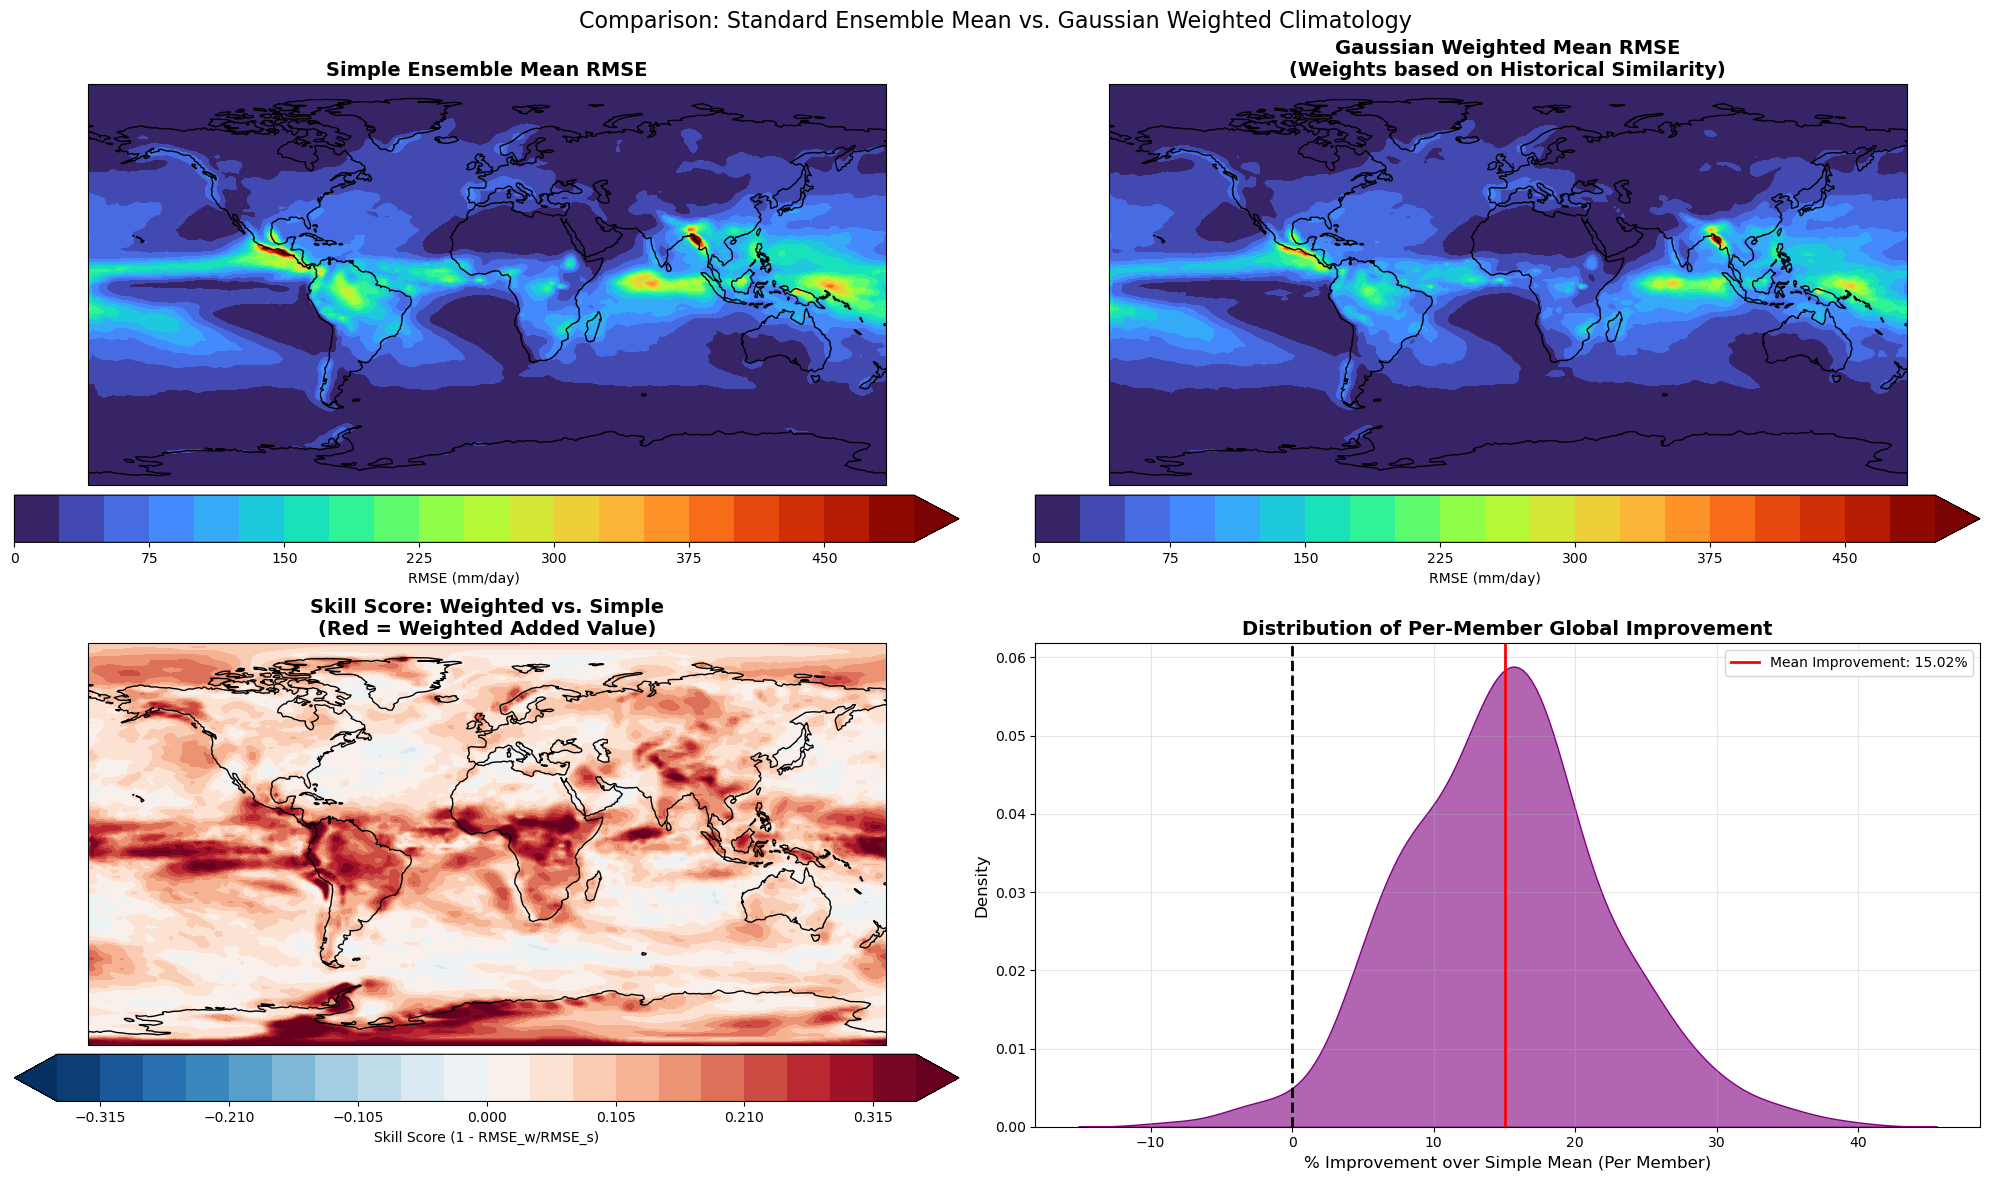

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import os
import warnings

# Suppress divide by zero warnings for ocean/nan points
warnings.filterwarnings("ignore")

# --------------------------
# Config / Paths
# --------------------------
data_dir   = "/Users/ewellmeyer/Documents/research/HadGEM"
input_file = os.path.join(data_dir, "GA789_PR_his_rg128.nc")
truth_file = os.path.join(data_dir, "GA789_dPdK_rg128.nc")
land_mask_file = os.path.join(data_dir, "hadgem_landmask_rg128.nc")
land_mask_var = "land_mask"

print("Loading data...")

# --------------------------
# Data Loading
# --------------------------
# Load Historical Climatology (Predictors)
ds_in = xr.open_dataset(input_file)
# Assuming structure is (Vars, Member, Lat, Lon) or (Member, Lat, Lon)
X_data = ds_in.to_array().values.squeeze()
ds_in.close()

# Load Truth/Change (Targets)
ds_true = xr.open_dataset(truth_file)
y_data = ds_true.to_array().values.squeeze()
ds_true.close()

# Handle dimensions if necessary (e.g. if there's a singleton channel dim)
# Expecting: (N_members, Lat, Lon)
if X_data.ndim == 4:  # (1, N, Lat, Lon)
    X_data = X_data[0]
if y_data.ndim == 4:
    y_data = y_data[0]

# Ensure shapes match
assert X_data.shape == y_data.shape, f"Shape mismatch: X {X_data.shape} vs y {y_data.shape}"

n_members, n_lat, n_lon = X_data.shape
print(f"Data Loaded. Shape: {X_data.shape} (Members, Lat, Lon)")

# Load coordinates (from one of the files)
ds_ref = xr.open_dataset(input_file)
lats = ds_ref["latitude"].values
lons = ds_ref["longitude"].values
ds_ref.close()

# Load Land Mask
print(f"Loading land mask from: {land_mask_file}")
try:
    ds_mask = xr.open_dataset(land_mask_file)
    # Check for likely variable names if specific one isn't found
    if land_mask_var not in ds_mask:
        land_mask_var = list(ds_mask.data_vars)[0]

    land_mask = ds_mask[land_mask_var].values

    # Handle simple shape mismatches (e.g. (1, Lat, Lon))
    if land_mask.ndim == 3:
        land_mask = land_mask[0]

    land_mask = land_mask.astype(bool)
    ds_mask.close()
    print(f"Land mask shape: {land_mask.shape}")
    print(f"Land points: {np.sum(land_mask)}, Ocean points: {np.sum(~land_mask)}")
except Exception as e:
    print(f"Warning: Could not load land mask: {e}")
    print("Using all points (no land mask applied)")
    land_mask = np.ones((n_lat, n_lon), dtype=bool)

# --------------------------
# Train/Test Split
# --------------------------
indices = np.arange(n_members)
train_idx, test_idx = train_test_split(indices, test_size=0.25, random_state=42)
print(f"Total members: {n_members}, Train: {len(train_idx)}, Test: {len(test_idx)}")

# Training library
X_train = X_data[train_idx]  # (n_train, lat, lon)
y_train = y_data[train_idx]  # (n_train, lat, lon)
n_train = X_train.shape[0]

# --------------------------
# Precompute weights & helpers
# --------------------------
print("\nPrecomputing member-wise weights...")

# Latitude weights (broadcastable to 2D)
lat_weights = np.cos(np.deg2rad(lats))          # (n_lat,)
area_weights_2d = np.broadcast_to(lat_weights[:, None], (n_lat, n_lon))

# Flatten for distance calculations
X_train_flat = X_train.reshape(n_train, -1)     # (n_train, n_pts)
X_all_flat   = X_data.reshape(n_members, -1)    # (n_members, n_pts)

area_weights_flat = area_weights_2d.reshape(-1)  # (n_pts,)

# --------------------------
# Set member-wise sigma scale (UPDATED)
# --------------------------
# Use spread of training members around their mean as distance scale
X_mean_train_flat = np.mean(X_train_flat, axis=0)  # (n_pts,)
diff_train = X_train_flat - X_mean_train_flat      # (n_train, n_pts)

# Area-weighted mean squared distance to ensemble mean for each training member
num = np.sum(diff_train**2 * area_weights_flat, axis=1)
den = np.sum(area_weights_flat)
D_train = num / den  # (n_train,)


sigma_scale = 8000 #np.median(D_train)

# Fallback just in case of degenerate data
if sigma_scale <= 0:
    sigma_scale = np.mean(D_train) if np.mean(D_train) > 0 else 1e-6

print(f"Member-wise sigma scale (Median MSE): {sigma_scale:.4e}")

# --------------------------
# Compute Predictions (Member-wise weights)
# --------------------------
print("\nComputing member-wise Gaussian-weighted predictions...")

# Simple ensemble-mean prediction (same for all members)
simple_mean_field = np.mean(y_train, axis=0)  # (lat, lon)

# Container for weighted predictions for ALL members
y_pred_weighted_all = np.zeros_like(y_data)   # (n_members, lat, lon)

for k in range(n_members):
    if k % 100 == 0:
        print(f"  Processing member {k+1}/{n_members}")

    # Full-field difference between target member and each training member
    diff_k = X_train_flat - X_all_flat[k]             # (n_train, n_pts)
    sq_diff_k = diff_k**2

    # Area-weighted MSE distance to each training member
    num_k = np.sum(sq_diff_k * area_weights_flat, axis=1)  # (n_train,)
    D_k = num_k / den

    # Formula: exp( -Distance / scale )
    # D_k is already squared (MSE), and sigma_scale is median MSE, so units match.
    # No need to square sigma_scale again.
    weights_k = np.exp(-D_k / sigma_scale)
    
    sum_w = np.sum(weights_k)

    if sum_w > 0:
        weights_k = weights_k / sum_w
    else:
        # This should theoretically not happen now with correct scaling
        weights_k = np.ones(n_train) / n_train

    # Weighted prediction for this member (linear combo of y_train fields)
    y_pred_weighted_all[k] = np.tensordot(weights_k, y_train, axes=(0, 0))

# --------------------------
# Spatial RMSE Maps (Test Set Only)
# --------------------------
print("\nComputing RMSE maps from test members...")

rmse_simple_map   = np.zeros((n_lat, n_lon))
rmse_weighted_map = np.zeros((n_lat, n_lon))

for k in test_idx:
    e_simple   = (simple_mean_field       - y_data[k])**2
    e_weighted = (y_pred_weighted_all[k] - y_data[k])**2

    rmse_simple_map   += e_simple
    rmse_weighted_map += e_weighted

n_test = len(test_idx)
rmse_simple_map   = np.sqrt(rmse_simple_map   / n_test)
rmse_weighted_map = np.sqrt(rmse_weighted_map / n_test)

# sigma_map now just stores the same scalar sigma_scale everywhere
sigma_map = np.full((n_lat, n_lon), sigma_scale, dtype=float)

# --------------------------
# Global & Land-Only RMSE per Member
# --------------------------
print("\nComputing global and land-only RMSE per member...")

# Broadcast lat weights to 2D and apply land mask
lat_weights_2d = np.broadcast_to(lat_weights[:, None], (n_lat, n_lon))
global_weights_2d = lat_weights_2d               # for all points
land_weights_2d   = lat_weights_2d * land_mask   # for land-only

total_weight_global = np.sum(global_weights_2d)
total_weight_land   = np.sum(land_weights_2d)

global_sse_simple_accum   = np.zeros(n_members)
global_sse_weighted_accum = np.zeros(n_members)

global_sse_simple_land_accum   = np.zeros(n_members)
global_sse_weighted_land_accum = np.zeros(n_members)

for k in range(n_members):
    e_simple   = (simple_mean_field       - y_data[k])**2
    e_weighted = (y_pred_weighted_all[k] - y_data[k])**2

    # Global
    global_sse_simple_accum[k]   = np.sum(e_simple   * global_weights_2d)
    global_sse_weighted_accum[k] = np.sum(e_weighted * global_weights_2d)

    # Land-only
    global_sse_simple_land_accum[k]   = np.sum(e_simple   * land_weights_2d)
    global_sse_weighted_land_accum[k] = np.sum(e_weighted * land_weights_2d)

# Convert SSE to RMSE
member_rmse_simple   = np.sqrt(global_sse_simple_accum   / total_weight_global)
member_rmse_weighted = np.sqrt(global_sse_weighted_accum / total_weight_global)

if total_weight_land > 0:
    member_rmse_simple_land   = np.sqrt(global_sse_simple_land_accum   / total_weight_land)
    member_rmse_weighted_land = np.sqrt(global_sse_weighted_land_accum / total_weight_land)
else:
    member_rmse_simple_land   = np.zeros_like(member_rmse_simple)
    member_rmse_weighted_land = np.zeros_like(member_rmse_weighted)

# --------------------------
# Summary & Save
# --------------------------
print("\n" + "="*50)
print("RESULTS SUMMARY (Member-wise Weights)")
print("="*50)
print(f"\nGlobal (All Points):")
print(f"  Simple mean RMSE (test):    {np.mean(member_rmse_simple[test_idx]):.4f}")
print(f"  Weighted mean RMSE (test):  {np.mean(member_rmse_weighted[test_idx]):.4f}")
print(f"\nLand Only:")
print(f"  Simple mean RMSE (test):    {np.mean(member_rmse_simple_land[test_idx]):.4f}")
print(f"  Weighted mean RMSE (test):  {np.mean(member_rmse_weighted_land[test_idx]):.4f}")

save_path = os.path.join(data_dir, "gaussian_weighted_analysis_memberwise_sig8000.npz")

np.savez_compressed(
    save_path,
    lats=lats.astype(np.float32),
    lons=lons.astype(np.float32),
    land_mask=land_mask.astype(bool),
    rmse_simple_map=rmse_simple_map.astype(np.float32),
    rmse_weighted_map=rmse_weighted_map.astype(np.float32),
    sigma_map=sigma_map.astype(np.float32),
    member_rmse_simple=member_rmse_simple.astype(np.float32),
    member_rmse_weighted=member_rmse_weighted.astype(np.float32),
    member_rmse_simple_land=member_rmse_simple_land.astype(np.float32),
    member_rmse_weighted_land=member_rmse_weighted_land.astype(np.float32),
    train_idx=train_idx.astype(np.int32),
    test_idx=test_idx.astype(np.int32),
    sigma_dist=np.float32(sigma_scale),  # store scalar
)

print(f"\nSaved member-wise results to: {save_path}")
import cartopy.crs as ccrs
import seaborn as sns

fig = plt.figure(figsize=(20, 12))

# Shared plotting settings
clevs = np.linspace(0, 500, 21)
cmap_rmse = 'turbo'

# 1. Simple Mean RMSE
ax1 = plt.subplot(2, 2, 1, projection=ccrs.PlateCarree())
im1 = ax1.contourf(lons, lats, rmse_simple_map, levels=clevs, cmap=cmap_rmse, extend="max", transform=ccrs.PlateCarree())
ax1.coastlines()
ax1.set_title('Simple Ensemble Mean RMSE', fontsize=14, fontweight='bold')
plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.02, label='RMSE (mm/day)')

# 2. Weighted Mean RMSE
ax2 = plt.subplot(2, 2, 2, projection=ccrs.PlateCarree())
im2 = ax2.contourf(lons, lats, rmse_weighted_map, levels=clevs, cmap=cmap_rmse, extend="max", transform=ccrs.PlateCarree())
ax2.coastlines()
ax2.set_title('Gaussian Weighted Mean RMSE\n(Weights based on Historical Similarity)', fontsize=14, fontweight='bold')
plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.02, label='RMSE (mm/day)')

# 3. Skill Map (Improvement)
# Positive values = Weighted method is better
ax3 = plt.subplot(2, 2, 3, projection=ccrs.PlateCarree())
skill = 1 - (rmse_weighted_map / rmse_simple_map)
# Cap visualization at +/- 50% improvement
clevs_skill = np.linspace(-0.35, 0.35, 21)
im3 = ax3.contourf(lons, lats, skill, levels=clevs_skill, cmap='RdBu_r', extend='both', transform=ccrs.PlateCarree())
ax3.coastlines()
ax3.set_title('Skill Score: Weighted vs. Simple\n(Red = Weighted Added Value)', fontsize=14, fontweight='bold')
plt.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.02, label='Skill Score (1 - RMSE_w/RMSE_s)')

# 4. Histogram of Improvement
ax4 = plt.subplot(2, 2, 4)

# Load the per-member data
member_rmse_simple = rmse_simple_map  # This is wrong - using spatial map
member_rmse_weighted = rmse_weighted_map  # This is wrong

# CORRECT VERSION:
# You need to load these from the saved file
data = np.load(os.path.join(data_dir, "gaussian_weighted_analysis_memberwise_sig8000.npz"))
member_rmse_simple_global = data['member_rmse_simple'][data['test_idx']]
member_rmse_weighted_global = data['member_rmse_weighted'][data['test_idx']]

# Per-member improvement
pct_improvement = (1 - member_rmse_weighted_global / member_rmse_simple_global) * 100

# Use existing pct_improvement array computed earlier
sns.kdeplot(pct_improvement, fill=True, color='purple', alpha=0.6, ax=ax4)

ax4.axvline(0, color='black', linestyle='--', linewidth=2)
mean_imp = np.mean(pct_improvement)
ax4.axvline(mean_imp, color='red', linestyle='-', linewidth=2, label=f'Mean Improvement: {mean_imp:.2f}%')

ax4.set_xlabel('% Improvement over Simple Mean (Per Member)', fontsize=12)
ax4.set_ylabel('Density', fontsize=12)
ax4.set_title('Distribution of Per-Member Global Improvement', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle("Comparison: Standard Ensemble Mean vs. Gaussian Weighted Climatology", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()